# Flight Fare Prediction

## Introduction

Flight ticket prices are highly dynamic and vary based on several factors such as airline, source, destination, duration, number of stops, and travel date. Predicting flight prices can help travelers make informed decisions and plan their journeys more effectively. In this project, Exploratory Data Analysis (EDA) and Machine Learning techniques are used to analyze flight fare data and build a predictive model for estimating flight ticket prices.

## Problem Statement

Flight ticket prices frequently change due to multiple operational and market factors, making it difficult for customers to estimate future fares. The objective of this project is to analyze historical flight data and develop a machine learning model capable of predicting flight prices based on factors such as airline, journey date, source, destination, duration, arrival time, departure time, and total stops.

## Objectives

- Perform comprehensive exploratory data analysis on the flight fare dataset.
- Identify key factors influencing flight ticket prices.
- Clean and preprocess the dataset for machine learning.
- Build multiple regression models for flight fare prediction.
- Compare model performance and select the best model.
- Help travelers estimate future flight prices and plan their journeys effectively.

## Dataset Source

Dataset Link:
https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/flight-fare.zip

The dataset contains historical flight information including airline details, source and destination cities, departure and arrival timings, flight duration, number of stops, and ticket prices.

## Feature Description

Airline: Name of the airline.  
Date_of_Journey: Date of travel.  
Source: Departure city.  
Destination: Arrival city.  
Route: Flight route.  
Dep_Time: Departure time.   
Arrival_Time: Arrival time.   
Duration: Total flight duration.   
Total_Stops: Number of stops during the journey.   
Additional_Info: Additional flight information.  
Price: Flight fare (Target Variable).   

## Import Libraries

In [1]:
# Data Manupulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train Test Split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evalution
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

- The required libraries for data manipulation, visualization, machine learning model development, and evaluation were imported.

## Load Dataset

In [2]:
df = pd.read_csv("Flight_Fare.csv")
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR ? DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL ? LKO ? BOM ? COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU ? NAG ? BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR ? NAG ? DEL,16:50,21:35,4h 45m,1 stop,No info,13302


## Data Understanding

### Dataset preview

In [3]:
df.head()


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR ? DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL ? LKO ? BOM ? COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU ? NAG ? BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR ? NAG ? DEL,16:50,21:35,4h 45m,1 stop,No info,13302


### Dataset Shape

In [4]:
df.shape

(10683, 11)

### Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


### Statistical Summary

In [6]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


## Missing Values Analysis

In [7]:
## Check Missing Values
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

- Only Route and Total_Stops columns contained missing values.
- The number of missing records was minimal, so they were removed.
- The dataset remained largely unaffected and ready for further preprocessing

## Handling Missing Values

In [8]:
## Remove missing Values
df.dropna(inplace=True)

## Verify
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

- Missing values were present in only a few records and were removed without significantly affecting the dataset.
- After handling missing values, the dataset became clean and suitable for further analysis and model building.

## Feature Engineering

### Date Of Journey Transformation

In [9]:
df["Journey_Day"] = pd.to_datetime(
    df["Date_of_Journey"],
    format="%d/%m/%Y"
).dt.day

df["Journey_Month"] = pd.to_datetime(
    df["Date_of_Journey"],
    format="%d/%m/%Y"
).dt.month

df.drop("Date_of_Journey", axis=1, inplace=True)

In [10]:
df[["Journey_Day","Journey_Month"]].head()

,Journey_Day,Journey_Month
0,24,3
1,1,5
2,9,6
3,12,5
4,1,3


- Journey date was converted into day and month features.
- These features help identify seasonal and monthly fare trends.

### Departure Time and Transformation

In [11]:
df["Dep_Hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour
df["Dep_Min"] = pd.to_datetime(df["Dep_Time"]).dt.minute

df.drop("Dep_Time", axis=1, inplace=True)

In [12]:
df[["Dep_Hour","Dep_Min"]].head()

,Dep_Hour,Dep_Min
0,22,20
1,5,50
2,9,25
3,18,5
4,16,50


- Departure time was converted into hour and minute features.
- These features help capture flight timing patterns that may influence ticket prices.

### Arrival Time Transformation

In [13]:
df["Arrival_Hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour
df["Arrival_Min"] = pd.to_datetime(df["Arrival_Time"]).dt.minute

df.drop("Arrival_Time", axis=1, inplace=True)

In [14]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_Day', 'Journey_Month', 'Dep_Hour',
       'Dep_Min', 'Arrival_Hour', 'Arrival_Min'],
      dtype='object')

- Arrival time was converted into hour and minute features.
- These features help capture flight arrival patterns and their impact on ticket prices.

### Duration Transformation

In [15]:
df["Duration_Hours"] = df["Duration"].str.extract("(\d+)h").fillna(0).astype(int)

df["Duration_Mins"] = df["Duration"].str.extract("(\d+)m").fillna(0).astype(int)

df.drop("Duration", axis=1, inplace=True)

df[["Duration_Hours","Duration_Mins"]].head()

,Duration_Hours,Duration_Mins
0,2,50
1,7,25
2,19,0
3,5,25
4,4,45


- Flight duration was converted into separate hour and minute features.
- This transformation makes the duration data suitable for machine learning models.

### Total_stops Transformation

In [16]:
## Check Unique Values
df["Total_Stops"].value_counts()

Total_Stops
1 stop      5625
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

In [17]:
df["Total_Stops"] = df["Total_Stops"].map({
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
})

In [18]:
df["Total_Stops"].head()

0    0
1    2
2    2
3    1
4    1
Name: Total_Stops, dtype: int64

- Total_Stops was converted into numerical values.
- This transformation enables machine learning models to process stop information effectively.

## Exploratory Data Analysis(EDA)

### Univariate Analysis

#### Airline Distribution

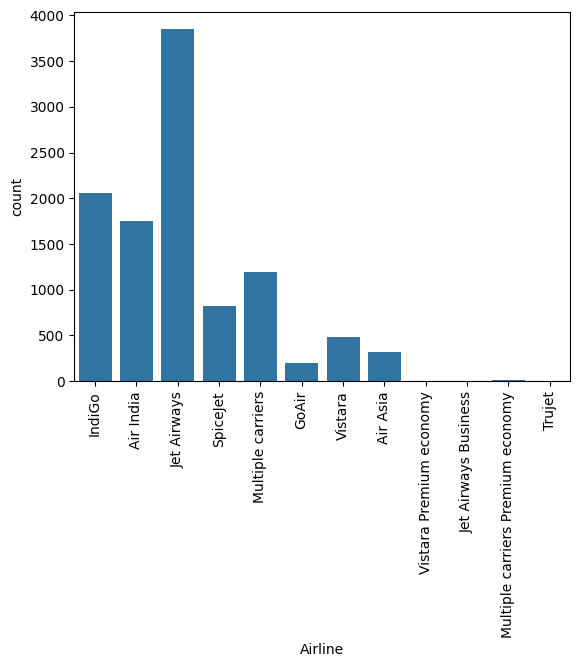

In [19]:
sns.countplot(x='Airline', data=df)
plt.xticks(rotation=90)
plt.show()

- Jet Airways has the highest number of flights in the dataset, indicating it is the most frequently represented airline.
- Indigo and Air India also have a significant presence, while airlines such as Trujet and Vistara Premium Economy have very few records.

#### Source Distribution

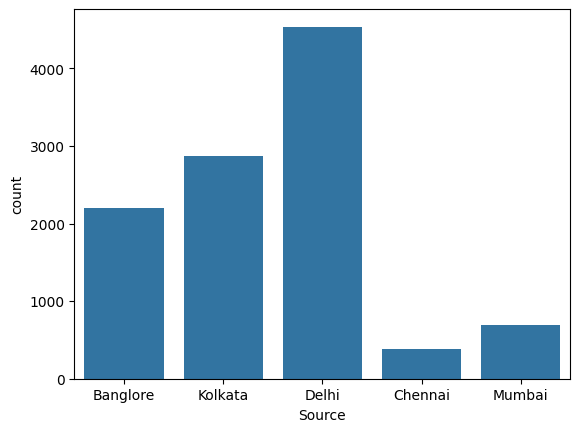

In [20]:
sns.countplot(x='Source', data=df)
plt.show()

- Delhi is the most common source city in the dataset, followed by Kolkata and Bangalore.
- Chennai and Mumbai contribute comparatively fewer flight records.

#### Destination Distribution

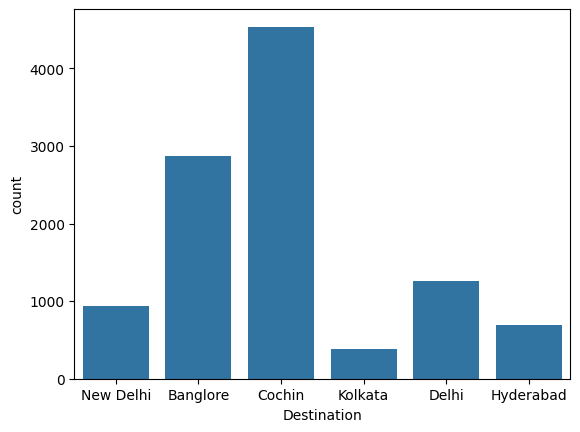

In [21]:
sns.countplot(x='Destination', data=df)
plt.show()

- Cochin is the most common destination in the dataset, followed by Bangalore.
- Kolkata has the lowest number of flight arrivals, indicating fewer records compared to other destinations.

#### Price Distribution

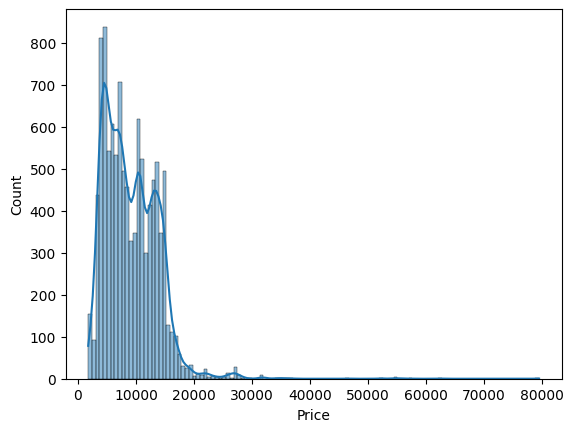

In [22]:
sns.histplot(df['Price'], kde=True)
plt.show()

- Flight prices are right-skewed, with most ticket prices concentrated between ₹3,000 and ₹15,000.
- A few very high-priced tickets create outliers, indicating premium or long-distance flights with significantly higher fares.

#### Total Stops Distribution

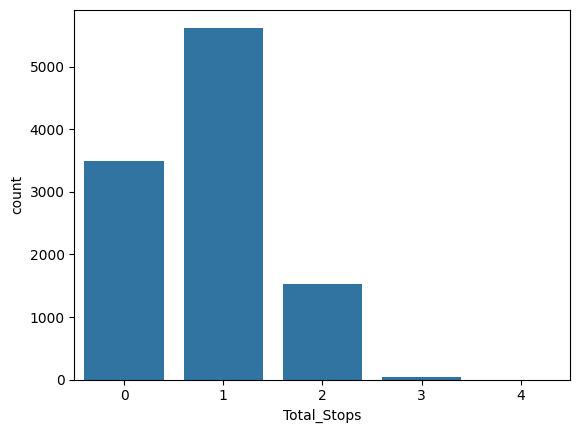

In [23]:
sns.countplot(x='Total_Stops', data=df)
plt.show()

- Most flights in the dataset have 1 stop, followed by non-stop flights, indicating these are the most common travel options.
- Flights with 3 or 4 stops are very rare, showing that passengers generally prefer routes with fewer stopovers.

### Bivariate Analysis

#### Airline VS Price

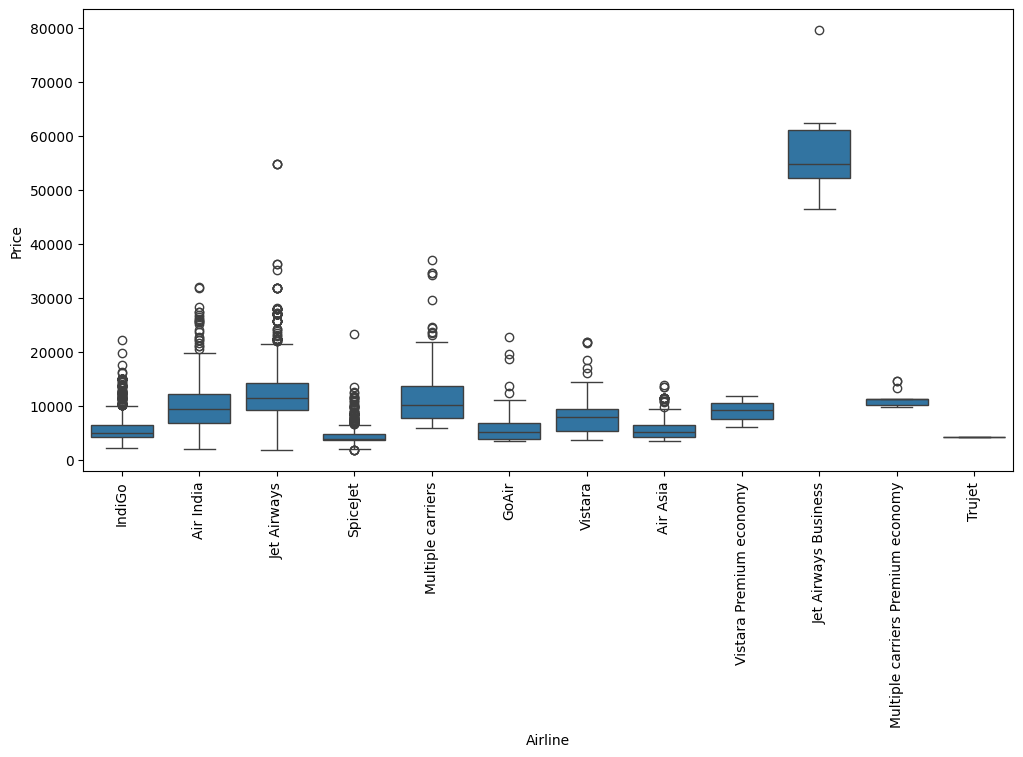

In [24]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Airline', y='Price', data=df)
plt.xticks(rotation=90)
plt.show()

- Flight prices vary significantly across airlines, indicating that the airline brand has a strong influence on ticket fares.
- Premium airlines such as Jet Airways Business show the highest ticket prices, while SpiceJet, IndiGo, and GoAir generally offer lower-priced flights.

#### Source vs Price

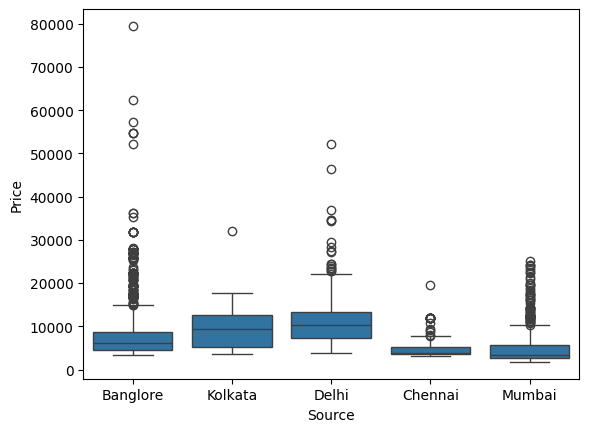

In [25]:
sns.boxplot(x='Source', y='Price', data=df)
plt.show()

- Flight prices vary across source cities, indicating that the departure location influences ticket fares.
- Flights originating from Delhi and Kolkata generally show higher median prices, while Chennai and Mumbai tend to have comparatively lower fares.

#### Total Stops VS Price

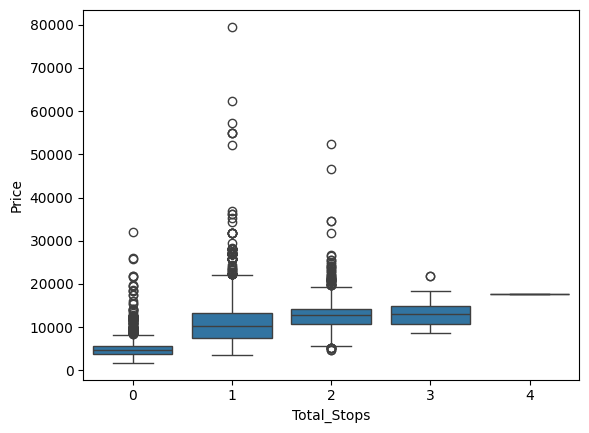

In [26]:
sns.boxplot(x='Total_Stops', y='Price', data=df)
plt.show()

- Flight prices generally increase as the number of stops increases, indicating that stopovers influence ticket fares.
- Non-stop flights have the lowest median fares, while flights with 2 or more stops tend to be more expensive and show greater price variation.

#### Duration Hours VS Price

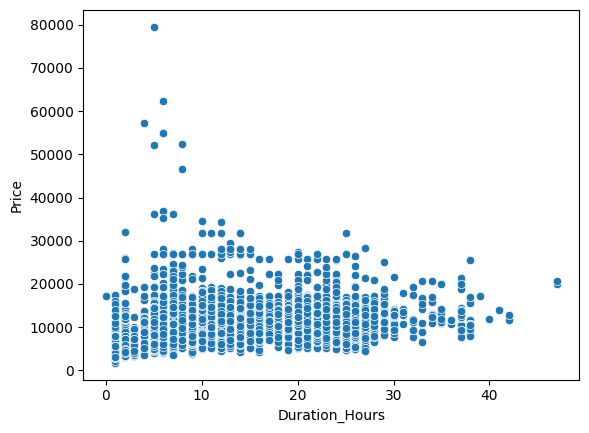

In [27]:
sns.scatterplot(x='Duration_Hours', y='Price', data=df)
plt.show()

- Flight fare generally increases as flight duration increases, indicating a positive relationship between travel time and ticket price.
- A few long-duration flights have exceptionally high fares, creating noticeable outliers in the dataset.

### Multivariate Analysis

### Pairplot

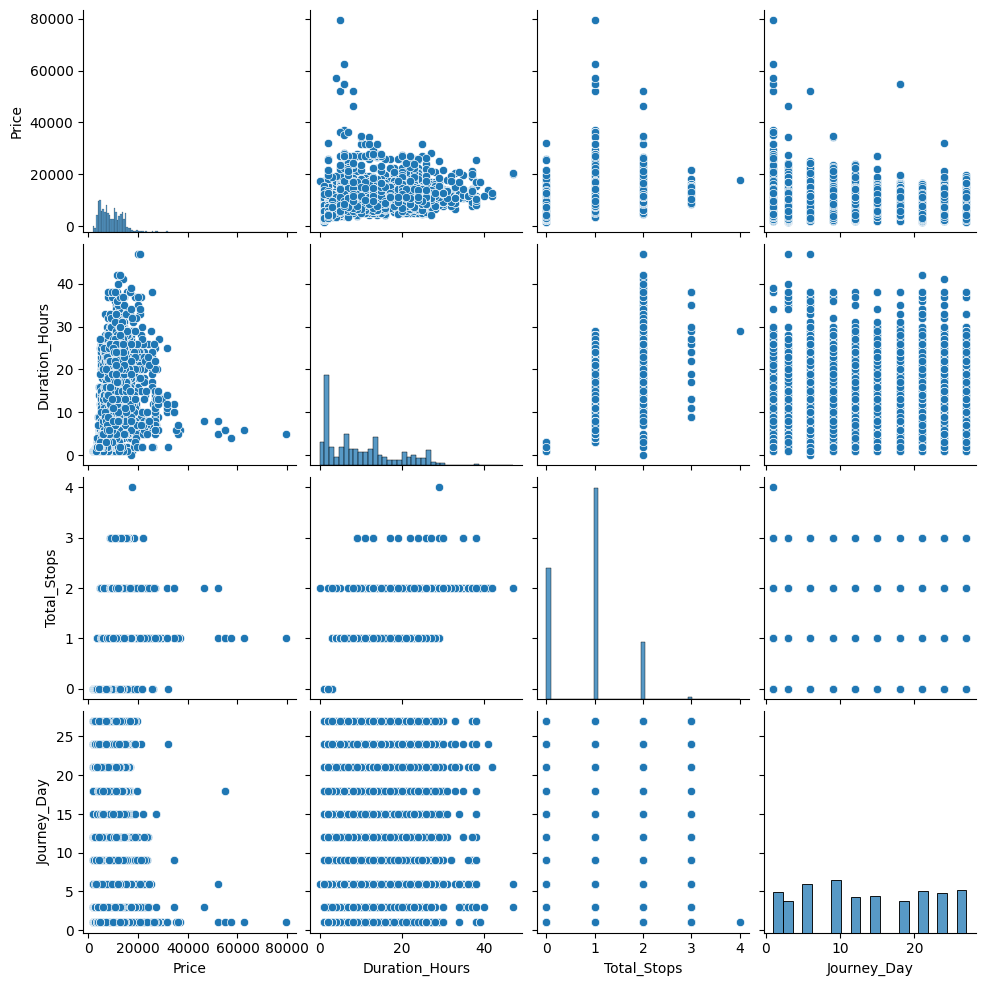

In [28]:
cols = ['Price', 'Duration_Hours', 'Total_Stops', 'Journey_Day']

sns.pairplot(df[cols])
plt.show()

- The pairplot shows a positive relationship between Price, Duration_Hours, and Total_Stops, indicating that longer flights with more stops generally have higher ticket prices.
- The distribution of multiple variables reveals useful patterns and interactions, helping identify the key factors influencing flight fare prediction.

### Correlation Heatmap

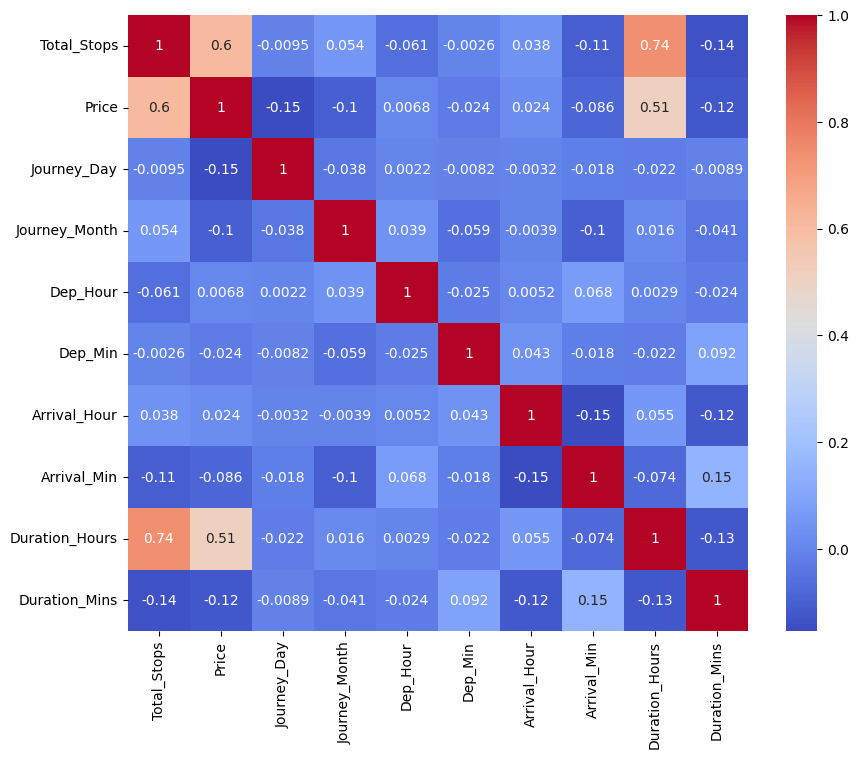

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

- Total_Stops (0.60) and Duration_Hours (0.51) have the strongest positive correlation with Price, indicating that longer flights with more stops tend to be more expensive.
- Most other numerical features show weak correlations with Price, suggesting that flight fare depends on multiple factors rather than a single feature.

## Feature Encoding

In [30]:
df = pd.get_dummies(df, drop_first=True)
print(df.shape)
df.head()

(10682, 166)


,Total_Stops,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hours,Duration_Mins,...,Route_MAA ? CCU,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No Info,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
0,0,3897,24,3,22,20,1,10,2,50,...,False,False,False,False,False,False,False,False,True,False
1,2,7662,1,5,5,50,13,15,7,25,...,False,False,False,False,False,False,False,False,True,False
2,2,13882,9,6,9,25,4,25,19,0,...,False,False,False,False,False,False,False,False,True,False
3,1,6218,12,5,18,5,23,30,5,25,...,False,False,False,False,False,False,False,False,True,False
4,1,13302,1,3,16,50,21,35,4,45,...,False,False,False,False,False,False,False,False,True,False


- Categorical features were transformed into numerical format using encoding techniques, making the data suitable for machine learning algorithms.
- Feature encoding increased the number of input variables and helped the model capture information from categories such as Airline, Source, Destination, and Route more effectively. 

## Feature & Target Split

In [31]:
X = df.drop("Price", axis=1)
y = df["Price"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (10682, 165)
y Shape: (10682,)


- Input features (X) and target variable (y) were separated successfully.
- X contains all predictors, while y contains the flight fare values to be predicted

## Train Test Split

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8545, 165)
X_test shape: (2137, 165)
y_train shape: (8545,)
y_test shape: (2137,)


- The data was split into training and testing sets to build and evaluate the model effectively.
- This approach helps assess how well the model generalizes to new, unseen data.

## Model Building

## Linear Regression

In [34]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

from sklearn.metrics import r2_score
print("R2 Score:", r2_score(y_test, y_pred_lr))

R2 Score: 0.7524642734149356


- Linear Regression achieved an R² score of 0.75, explaining approximately 75% of the variance in flight prices.
- Its performance is lower than Random Forest, indicating that flight fare prediction involves complex non-linear relationships.

## Decision Tree Regressor

In [35]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_dt))

R2 Score: 0.855304323057263


- Decision Tree achieved an R² score of 0.86, explaining approximately 86% of the variance in flight prices.
- It performed better than Linear Regression but slightly lower than Random Forest in predicting flight fares.

## Random Forest Regressor

In [36]:
# Model
rf = RandomForestRegressor(random_state=42)

# Train
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 609.5473565597819
MSE: 2594400.366459389
RMSE: 1610.7142410928727
R2 Score: 0.8796775072165922


- The Random Forest model achieved an R² score of 0.88, indicating that it explains approximately 88% of the variation in flight prices, demonstrating strong predictive performance.
- The RMSE of 1610.71 and MAE of 609.55 suggest that the model's prediction errors are relatively low compared to the overall price range, making it suitable for flight fare prediction.

## Actual vs Predicted Plot

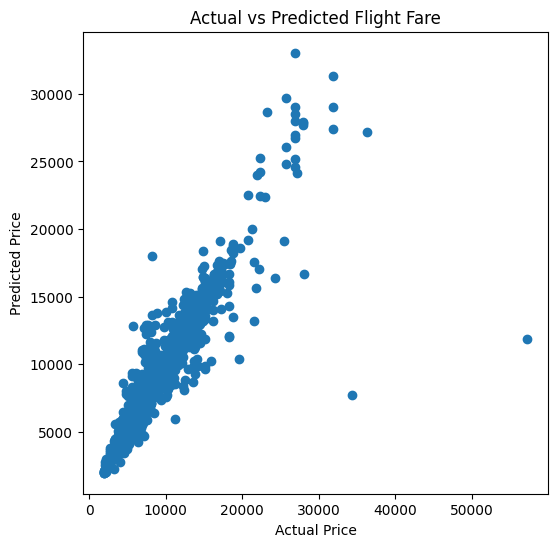

In [37]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Fare")
plt.show()

- Most data points follow a diagonal trend, indicating a strong agreement between actual and predicted flight fares and demonstrating good model performance.
- The close alignment of points around the diagonal line suggests that the Random Forest model predicts flight prices with high accuracy and minimal error.

## Hyper Parameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best R2 Score:", random_search.best_score_)

In [ ]:
from sklearn.metrics import r2_score

best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)

print("Test R2 Score:", r2_score(y_test, y_pred))

- Hyperparameter tuning improved the Random Forest model performance from 0.8797 to 0.8802 by optimizing key parameters.
- The Tuned Random Forest achieved the highest R² score and was selected as the final model for flight fare prediction.

## Model Comparison

In [ ]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree Regressor", "Random Forest Regressor"],
    "R2 Score": [0.7525, 0.8553, 0.8797]
})

model_comparison

- Among all the models, Random Forest Regressor achieved the highest R² score of 0.8797, indicating the best predictive performance for flight fare prediction.
- Linear Regression showed the lowest performance, while Decision Tree performed better, suggesting that non-linear models are more effective for capturing flight price patterns.

## Model Comparison Chart

In [ ]:
models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'Tuned RF']
scores = [0.7525, 0.8553, 0.8797, 0.8802]

plt.figure(figsize=(8,5))
plt.bar(models, scores)
plt.ylabel('R² Score')
plt.title('Model Comparison')
plt.show()

- The Tuned Random Forest Regressor achieved the highest R² score (0.8802), outperforming Linear Regression, Decision Tree, and the original Random Forest model.
- The comparison shows that ensemble-based models provide better prediction accuracy for flight fare prediction, making Tuned Random Forest the most suitable model. 

## Feature Importance

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

- Duration_Hours is the most influential feature with an importance score of 42.35%, indicating that flight duration has the strongest impact on ticket prices.
- Features such as Journey_Day, Airline type, Additional Information, and Total_Stops also contribute significantly to fare prediction, showing that flight prices depend on multiple travel-related factors.

## Feature Importance Graph

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.title('Top 10 Important Features')
plt.xlabel('Importance')
plt.show()

- The feature importance chart clearly shows that only a few features contribute heavily to fare prediction, while the remaining features have a relatively smaller impact.
- Flight duration dominates all other variables, indicating that ticket prices are largely influenced by the length of the journey and travel-related characteristics

## Challenges Faced

- Handling date and time features required multiple transformations to extract meaningful information such as journey day, month, departure hour, and arrival hour.

- Converting categorical features like Airline, Source, Destination, and Route into numerical format was necessary before model training.


- Flight duration data was available in text format and required preprocessing to create machine-learning-friendly features.
- Selecting the best model required comparing multiple algorithms and evaluating their performance using appropriate metrics.
- Managing a large number of features after encoding increased dataset complexity and required careful feature analysis.

## Techniques Used

- Feature Engineering for date, time, and duration columns.
- One-Hot Encoding for categorical variables.
- Train-Test Split for model validation.
- Linear Regression, Decision Tree, and Random Forest for model comparison.
- Feature Importance Analysis to identify key factors affecting flight prices.

## Project Summary

- Developed a Flight Fare Prediction model using machine learning techniques.
- Performed data cleaning, feature engineering, exploratory data analysis, and feature encoding.
- Built and evaluated Linear Regression, Decision Tree Regressor, and Random Forest Regressor models.
- Applied Hyperparameter Tuning to improve model performance.
- The Tuned Random Forest Regressor achieved the highest R² score of 0.8802 and was selected as the final model.
- Duration_Hours, Journey_Day, Airline, and Total_Stops were identified as the most important factors influencing flight ticket prices.

## Conclusion

* This project successfully developed a machine learning model to predict flight ticket prices based on various flight-related features such as airline, source, destination, duration, total stops, and journey date. Extensive data preprocessing, feature engineering, and exploratory data analysis were performed to understand the factors influencing flight fares.

* Among the models evaluated, the Tuned Random Forest Regressor achieved the highest R² score of 0.8802, outperforming Linear Regression and Decision Tree Regressor. Feature importance analysis revealed that flight duration, journey date, airline type, and total stops were the most influential factors affecting ticket prices. Therefore, the Tuned Random Forest model was selected as the final model due to its strong predictive performance and reliability in flight fare prediction.


## Future Scope

- The model can be deployed as a web application using Streamlit to provide real-time flight fare predictions.
    
- Additional features such as airline ratings, holiday seasons, weather conditions, and real-time booking data can be incorporated to improve prediction accuracy.
    
- Advanced machine learning algorithms such as XGBoost and LightGBM can be explored for better performance.
- The system can be integrated with travel booking platforms to assist users in making cost-effective travel decisions.